# FFT Signal Analysis of dir_val Traces — Grouped by Score

Analyze frequency content of fly PER traces (frames 0–3600, 90s at 40fps) grouped by
human-scored response values (0–5) from `new_scoring_ordered_complete1.csv`.

**Goals:**
1. Do scored 0s (no response) have different frequency content than 3s, 4s, 5s (strong response)?
2. Are there noise/tracking frequencies common to ALL scores?
3. Are there frequencies that emerge specifically in high-score traces?
4. Does frequency content shift around odor onset differently by score?

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from scipy.fft import fft, fftfreq
from scipy.stats import kruskal, mannwhitneyu
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

# Color map for scores 0-5 (cool->warm = low->high response)
SCORE_COLORS = {
    0: '#3274A1',  # blue (no response)
    1: '#5EA4C1',  # light blue
    2: '#8DC63F',  # green
    3: '#F5C542',  # yellow
    4: '#E8912D',  # orange
    5: '#E23E28',  # red
}

## 1. Load & Merge: Traces + Scores

In [3]:
# Load trace data
traces_df = pd.read_csv('../data/all_envelope_rows_wide_combined_base.csv')
print(f'Trace rows: {len(traces_df)}')

# Load scores
scores_df = pd.read_csv('../data/new_scoring_ordered_complete1.csv')

# Remap score 6 -> 5 (all 6s were meant to be 5s)
scores_df['user_score_odor'] = scores_df['user_score_odor'].replace(6, 5)

print(f'Score rows: {len(scores_df)}')
print(f'Score distribution:\n{scores_df["user_score_odor"].value_counts().sort_index()}')

Trace rows: 4394
Score rows: 1930
Score distribution:
user_score_odor
0    1102
1     223
2     210
3     171
4     111
5     113
Name: count, dtype: int64


In [4]:
# Dataset name mapping: scoring CSV -> trace CSV
DATASET_MAP = {
    'opto_3-oct': '3OCT-Training',
    'opto_ACV': 'ACV-Training',
    'opto_AIR': 'AIR-Training',
    'Benz_control': 'Benz-Control',
    'opto_benz_1': 'Benz-Training',
    'opto_benz_1-flagged': 'Benz-Training-flagged',
    'EB_control': 'EB-Control',
    'opto_EB': 'EB-Training',
    'opto_EB(6-training)': 'EB-Training(No-Operant)',
    'opto_EB-flagged': 'EB-Training-flagged',
    'hex_control': 'Hex-Control',
    'hex_control-flagged': 'Hex-Control-flagged',
    'opto_hex': 'Hex-Training',
    'opto_hex-flagged': 'Hex-Training-flagged',
}

scores_df['dataset_mapped'] = scores_df['dataset'].map(DATASET_MAP)
scores_df['trial_base'] = scores_df['trial_label']  # already 'testing_1', etc.

# Extract join keys from trace data
# trial_label like 'testing_1_fly1_angle_distance_rms_envelope'
traces_df['trial_base'] = traces_df['trial_label'].str.extract(r'^(testing_\d+)')
traces_df['trace_fly_num'] = traces_df['trial_label'].str.extract(r'fly(\d+)_')[0].astype(int)

# Use only the base trace type (angle_distance_rms_envelope, not the distances variants)
base_trace_mask = traces_df['trial_label'].str.match(r'^testing_\d+_fly\d+_angle_distance_rms_envelope$')
traces_base = traces_df[base_trace_mask].copy()
print(f'Base trace type rows: {len(traces_base)}')

# Merge
merged = traces_base.merge(
    scores_df[['dataset_mapped', 'fly', 'fly_number', 'trial_base', 'user_score_odor']],
    left_on=['dataset', 'fly', 'trace_fly_num', 'trial_base'],
    right_on=['dataset_mapped', 'fly', 'fly_number', 'trial_base'],
    how='inner'
)

print(f'\nMerged rows: {len(merged)}')
print(f'Score distribution after merge:')
print(merged['user_score_odor'].value_counts().sort_index())
print(f'\nDatasets represented: {sorted(merged["dataset"].unique())}')

Base trace type rows: 1

Merged rows: 1
Score distribution after merge:
user_score_odor
0    1
Name: count, dtype: int64

Datasets represented: ['Benz-Training']


In [5]:
# Extract dir_val frames 0-3600
FPS = 40
dir_cols = [f'dir_val_{i}' for i in range(3601)]
dir_cols = [c for c in dir_cols if c in merged.columns]
print(f'Using {len(dir_cols)} dir_val columns')

traces_mat = merged[dir_cols].values
scores_arr = merged['user_score_odor'].values

# Drop rows with NaN
valid_mask = ~np.isnan(traces_mat).any(axis=1)
traces_mat = traces_mat[valid_mask]
scores_arr = scores_arr[valid_mask]
merged_valid = merged[valid_mask].copy()
print(f'Valid traces: {len(traces_mat)} (dropped {(~valid_mask).sum()} NaN rows)')
print(f'Score distribution (valid):')
print(pd.Series(scores_arr).value_counts().sort_index())

N = traces_mat.shape[1]
t = np.arange(N) / FPS  # time in seconds
unique_scores = sorted(np.unique(scores_arr))
print(f'\nUnique scores: {unique_scores}')

Using 3601 dir_val columns
Valid traces: 1 (dropped 0 NaN rows)
Score distribution (valid):
0    1
Name: count, dtype: int64

Unique scores: [0]


## 2. Raw Traces by Score

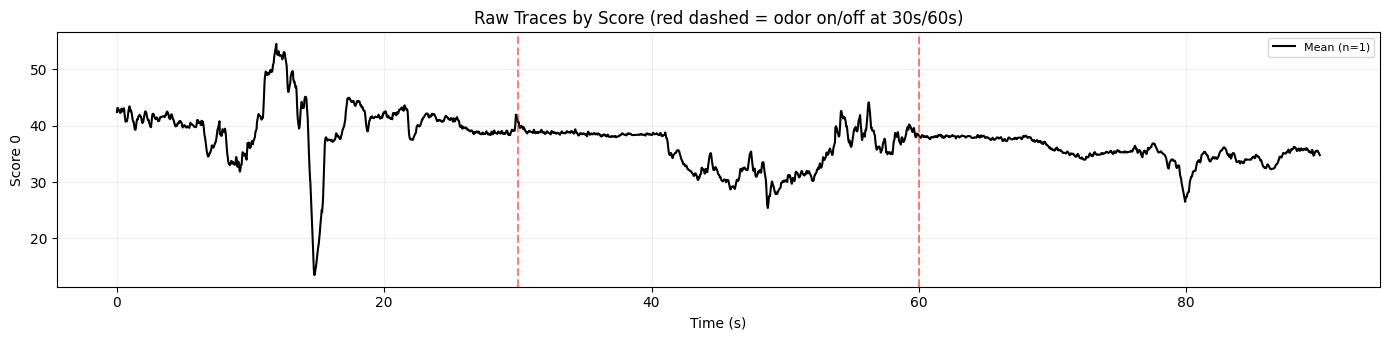

In [6]:
fig, axes = plt.subplots(len(unique_scores), 1, figsize=(14, 3.5 * len(unique_scores)), sharex=True, sharey=True)
if len(unique_scores) == 1:
    axes = [axes]

rng = np.random.default_rng(42)

for ax, score in zip(axes, unique_scores):
    mask = scores_arr == score
    n = mask.sum()
    # Plot up to 15 random traces
    idx = np.where(mask)[0]
    sample = rng.choice(idx, size=min(15, len(idx)), replace=False)
    for i in sample:
        ax.plot(t, traces_mat[i], alpha=0.3, linewidth=0.5, color=SCORE_COLORS.get(score, 'gray'))
    # Mean
    ax.plot(t, traces_mat[mask].mean(axis=0), color='black', linewidth=1.5, label=f'Mean (n={n})')
    ax.axvline(30, color='red', linestyle='--', alpha=0.5)
    ax.axvline(60, color='red', linestyle='--', alpha=0.5)
    ax.set_ylabel(f'Score {score}')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.2)

axes[-1].set_xlabel('Time (s)')
axes[0].set_title('Raw Traces by Score (red dashed = odor on/off at 30s/60s)')
plt.tight_layout()
plt.show()

## 3. FFT Power Spectra by Score

For each trace: subtract mean, apply Hann window, compute FFT power.

In [7]:
window = np.hanning(N)
freqs = fftfreq(N, d=1/FPS)[:N//2]

power_spectra = np.zeros((len(traces_mat), N//2))
for i, trace in enumerate(traces_mat):
    centered = trace - np.mean(trace)
    windowed = centered * window
    yf = fft(windowed)
    power_spectra[i] = 2.0/N * np.abs(yf[:N//2])**2

print(f'Power spectra shape: {power_spectra.shape}')
print(f'Freq resolution: {freqs[1]-freqs[0]:.4f} Hz, Nyquist: {freqs[-1]:.1f} Hz')

Power spectra shape: (1, 1800)
Freq resolution: 0.0111 Hz, Nyquist: 20.0 Hz


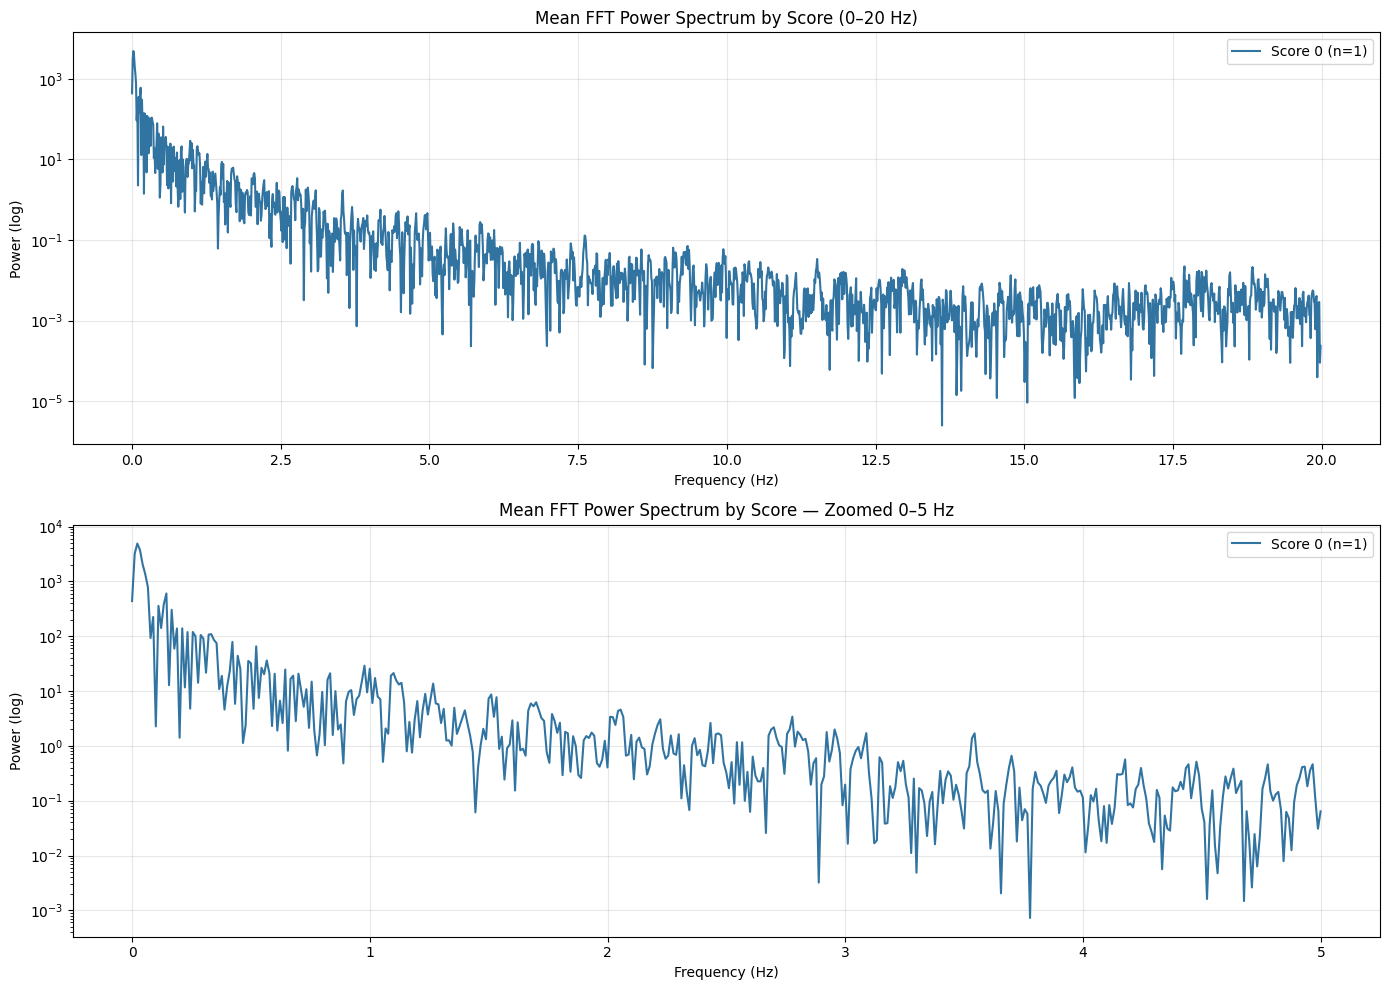

In [8]:
# Mean power spectrum per score — overlay plot
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Full range
ax = axes[0]
for score in unique_scores:
    mask = scores_arr == score
    mean_pwr = np.mean(power_spectra[mask], axis=0)
    ax.semilogy(freqs, mean_pwr, label=f'Score {score} (n={mask.sum()})',
                color=SCORE_COLORS.get(score, 'gray'), linewidth=1.5)
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Power (log)')
ax.set_title('Mean FFT Power Spectrum by Score (0–20 Hz)')
ax.legend()
ax.grid(True, alpha=0.3)

# Zoomed 0–5 Hz
ax = axes[1]
low_mask = freqs <= 5
for score in unique_scores:
    mask = scores_arr == score
    mean_pwr = np.mean(power_spectra[mask], axis=0)
    ax.semilogy(freqs[low_mask], mean_pwr[low_mask], label=f'Score {score} (n={mask.sum()})',
                color=SCORE_COLORS.get(score, 'gray'), linewidth=1.5)
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Power (log)')
ax.set_title('Mean FFT Power Spectrum by Score — Zoomed 0–5 Hz')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

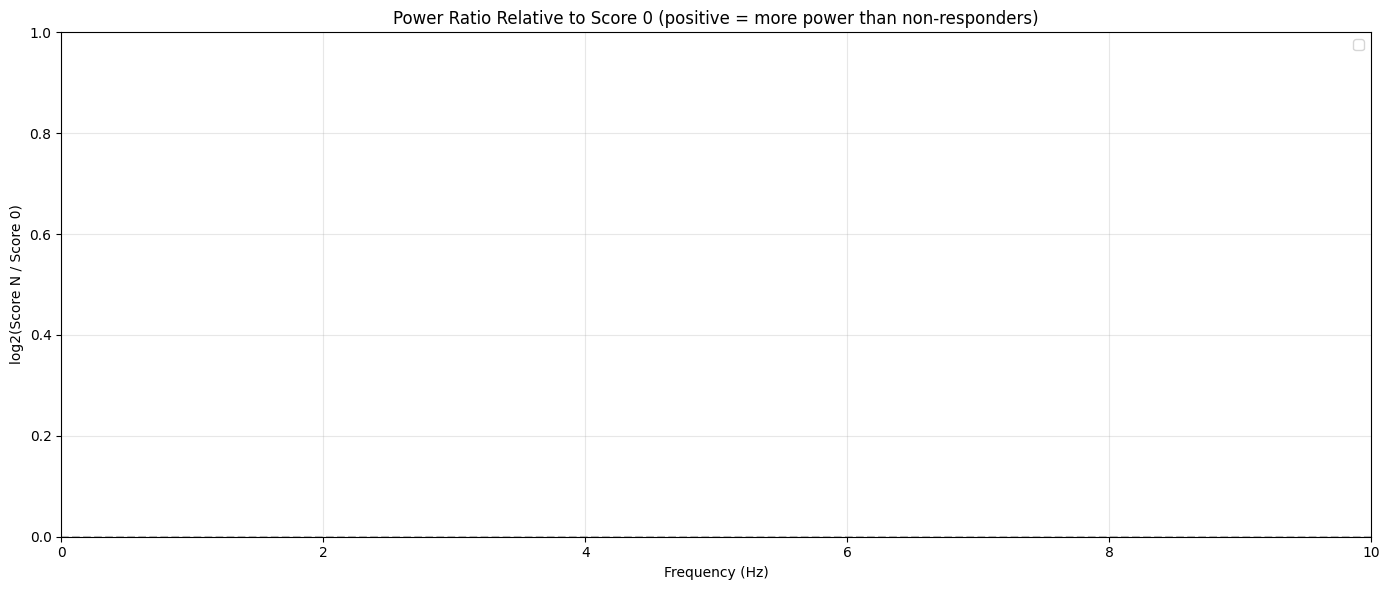

In [9]:
# Log ratio relative to Score 0 (baseline)
score0_mask = scores_arr == 0
mean_pwr_0 = np.mean(power_spectra[score0_mask], axis=0)

fig, ax = plt.subplots(figsize=(14, 6))
for score in unique_scores:
    if score == 0:
        continue
    mask = scores_arr == score
    mean_pwr = np.mean(power_spectra[mask], axis=0)
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = np.log2(mean_pwr / mean_pwr_0)
    ax.plot(freqs, ratio, label=f'Score {score} vs 0',
            color=SCORE_COLORS.get(score, 'gray'), linewidth=1.2)

ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('log2(Score N / Score 0)')
ax.set_title('Power Ratio Relative to Score 0 (positive = more power than non-responders)')
ax.set_xlim(0, 10)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Welch PSD by Score (Smoother Estimate)

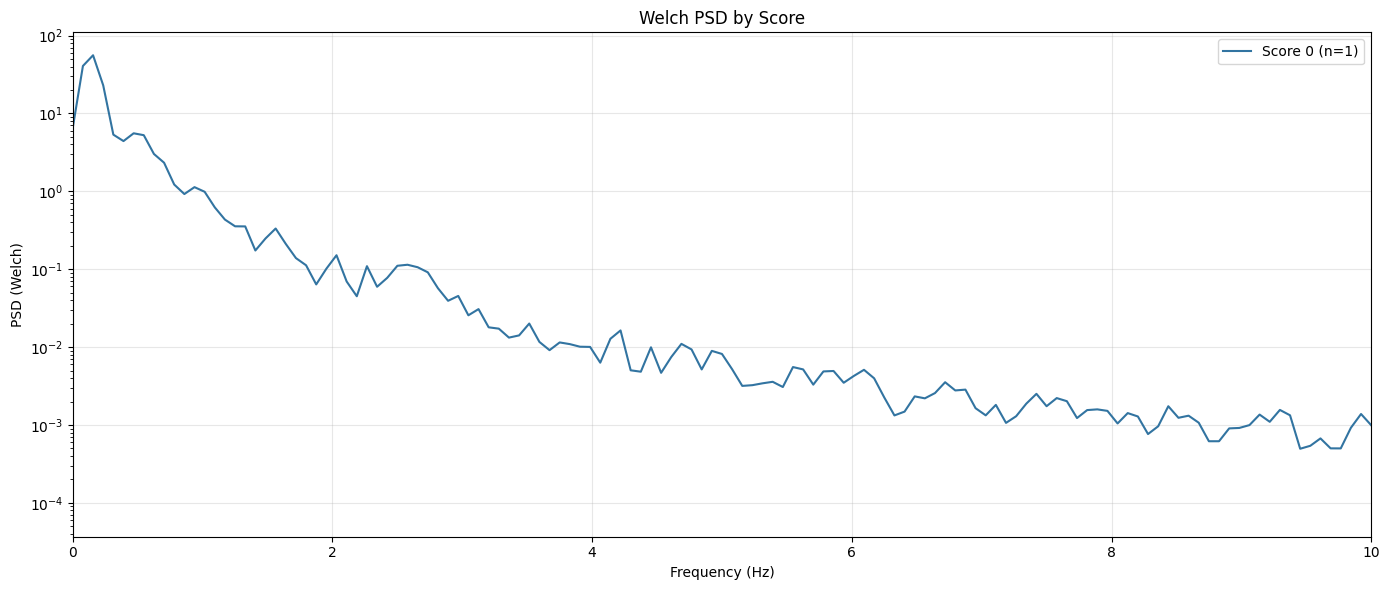

In [10]:
nperseg = 512  # ~12.8s windows

welch_psds = []
for trace in traces_mat:
    f_welch, pxx = signal.welch(trace - np.mean(trace), fs=FPS, nperseg=nperseg, noverlap=nperseg//2)
    welch_psds.append(pxx)
welch_psds = np.array(welch_psds)

fig, ax = plt.subplots(figsize=(14, 6))
for score in unique_scores:
    mask = scores_arr == score
    ax.semilogy(f_welch, np.mean(welch_psds[mask], axis=0),
                label=f'Score {score} (n={mask.sum()})',
                color=SCORE_COLORS.get(score, 'gray'), linewidth=1.5)
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('PSD (Welch)')
ax.set_title('Welch PSD by Score')
ax.set_xlim(0, 10)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Frequency Prevalence by Score

For each score group: what fraction of traces have a peak at each frequency?

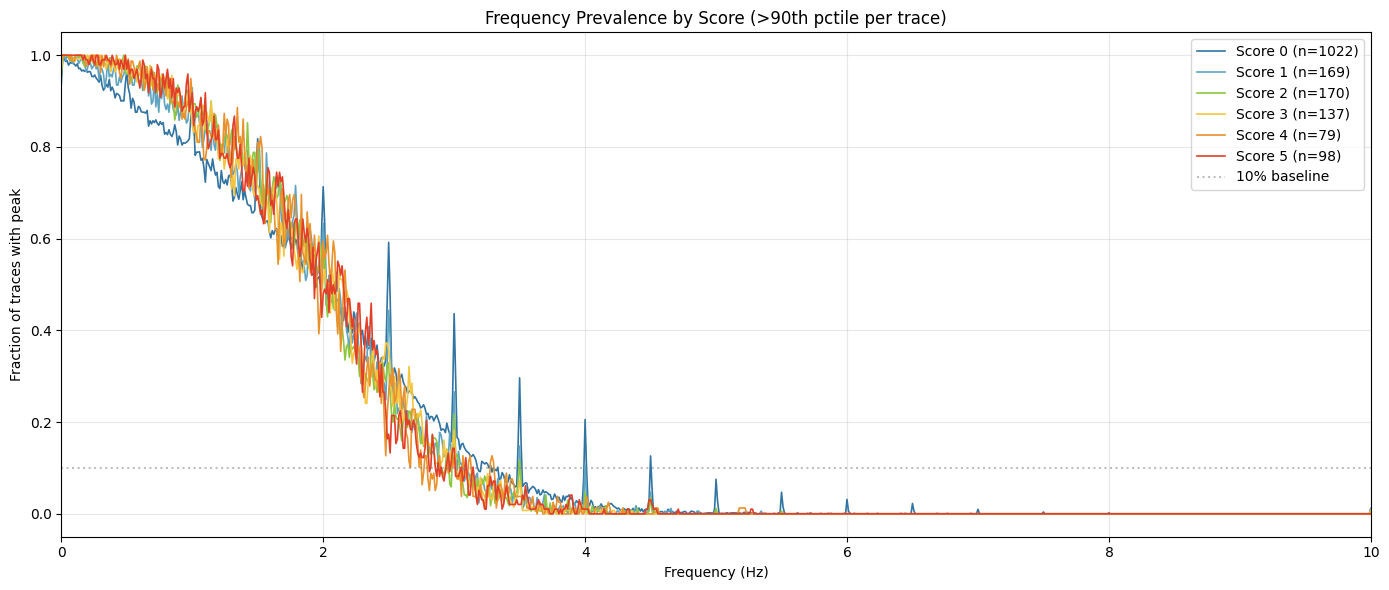

In [19]:
# Per-trace threshold: frequency is a "peak" if power > 90th percentile of that trace
thresholds = np.percentile(power_spectra, 90, axis=1, keepdims=True)
above_thresh = power_spectra > thresholds

fig, ax = plt.subplots(figsize=(14, 6))
for score in unique_scores:
    mask = scores_arr == score
    prevalence = above_thresh[mask].mean(axis=0)
    ax.plot(freqs, prevalence, label=f'Score {score} (n={mask.sum()})',
            color=SCORE_COLORS.get(score, 'gray'), linewidth=1.2)

ax.axhline(0.1, color='gray', linestyle=':', alpha=0.5, label='10% baseline')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Fraction of traces with peak')
ax.set_title('Frequency Prevalence by Score (>90th pctile per trace)')
ax.set_xlim(0, 10)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Spectrograms by Score

Time-frequency analysis showing how frequency content evolves around odor onset/offset for each score.

In [20]:
nperseg_spec = 256

def compute_avg_spectrogram(trace_matrix, fps, nperseg):
    spectrograms = []
    for trace in trace_matrix:
        f_s, t_s, Sxx = signal.spectrogram(
            trace - np.mean(trace), fs=fps, nperseg=nperseg, noverlap=nperseg//2
        )
        spectrograms.append(Sxx)
    return f_s, t_s, np.mean(spectrograms, axis=0)

# Compute for each score
spectrograms_by_score = {}
for score in unique_scores:
    mask = scores_arr == score
    if mask.sum() < 5:  # skip tiny groups
        continue
    f_s, t_s, Sxx = compute_avg_spectrogram(traces_mat[mask], FPS, nperseg_spec)
    spectrograms_by_score[score] = Sxx
    print(f'Score {score}: computed spectrogram from {mask.sum()} traces')

plot_scores = [s for s in unique_scores if s in spectrograms_by_score]

Score 0: computed spectrogram from 1022 traces
Score 1: computed spectrogram from 169 traces
Score 2: computed spectrogram from 170 traces
Score 3: computed spectrogram from 137 traces
Score 4: computed spectrogram from 79 traces
Score 5: computed spectrogram from 98 traces


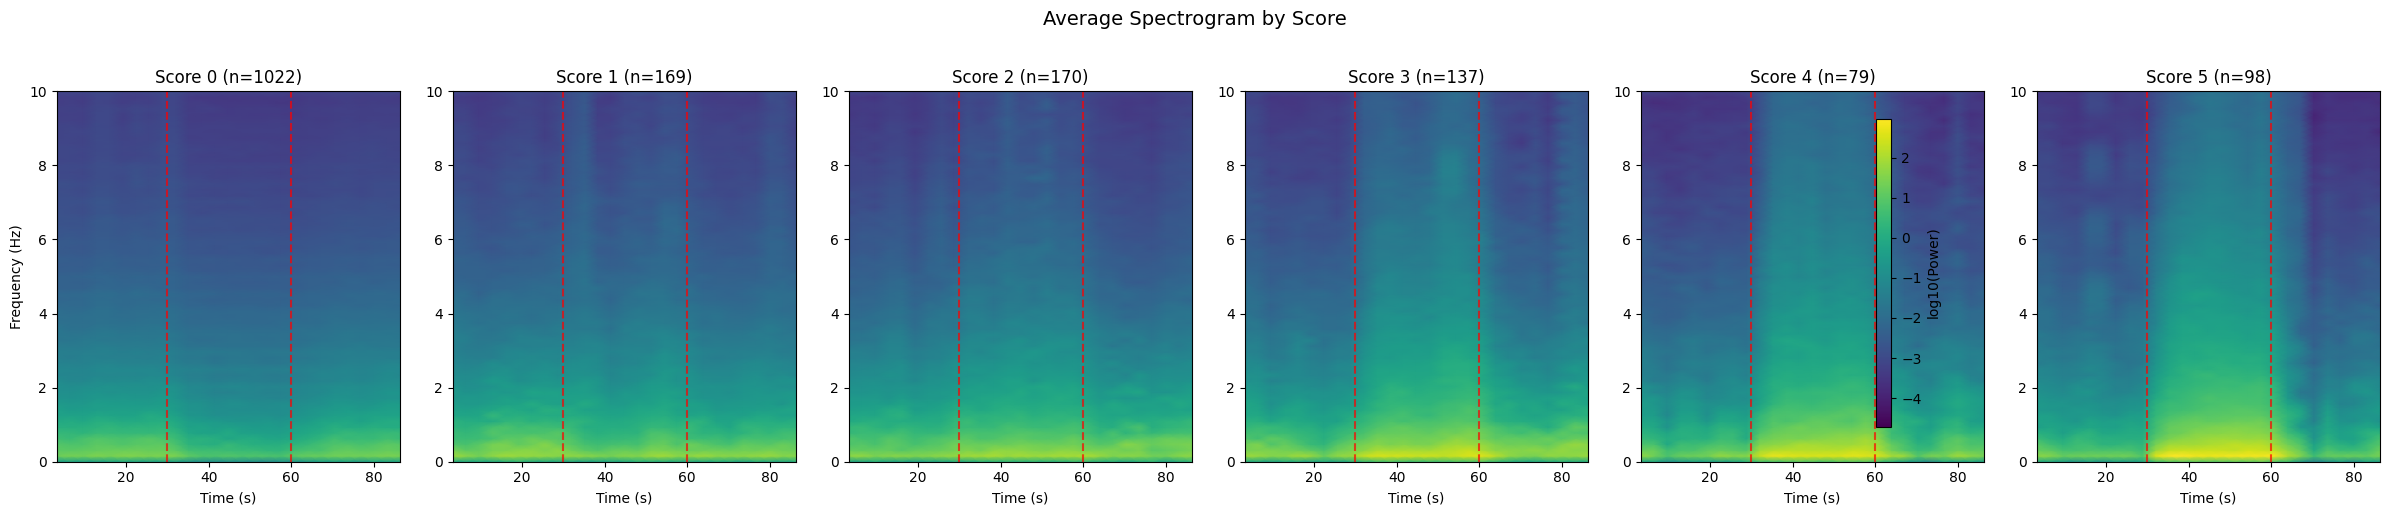

In [21]:
# Individual spectrograms per score
n_scores = len(plot_scores)
fig, axes = plt.subplots(1, n_scores, figsize=(4 * n_scores, 5))
if n_scores == 1:
    axes = [axes]

# Common color scale
all_log = [np.log10(spectrograms_by_score[s] + 1e-10) for s in plot_scores]
vmin = min(a.min() for a in all_log)
vmax = max(a.max() for a in all_log)

for ax, score, log_sxx in zip(axes, plot_scores, all_log):
    im = ax.pcolormesh(t_s, f_s, log_sxx, shading='gouraud', vmin=vmin, vmax=vmax)
    ax.set_title(f'Score {score} (n={int((scores_arr==score).sum())})')
    ax.set_ylim(0, 10)
    ax.axvline(30, color='r', linestyle='--', alpha=0.7)
    ax.axvline(60, color='r', linestyle='--', alpha=0.7)
    ax.set_xlabel('Time (s)')
    if ax == axes[0]:
        ax.set_ylabel('Frequency (Hz)')

plt.colorbar(im, ax=axes, label='log10(Power)', shrink=0.8)
fig.suptitle('Average Spectrogram by Score', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

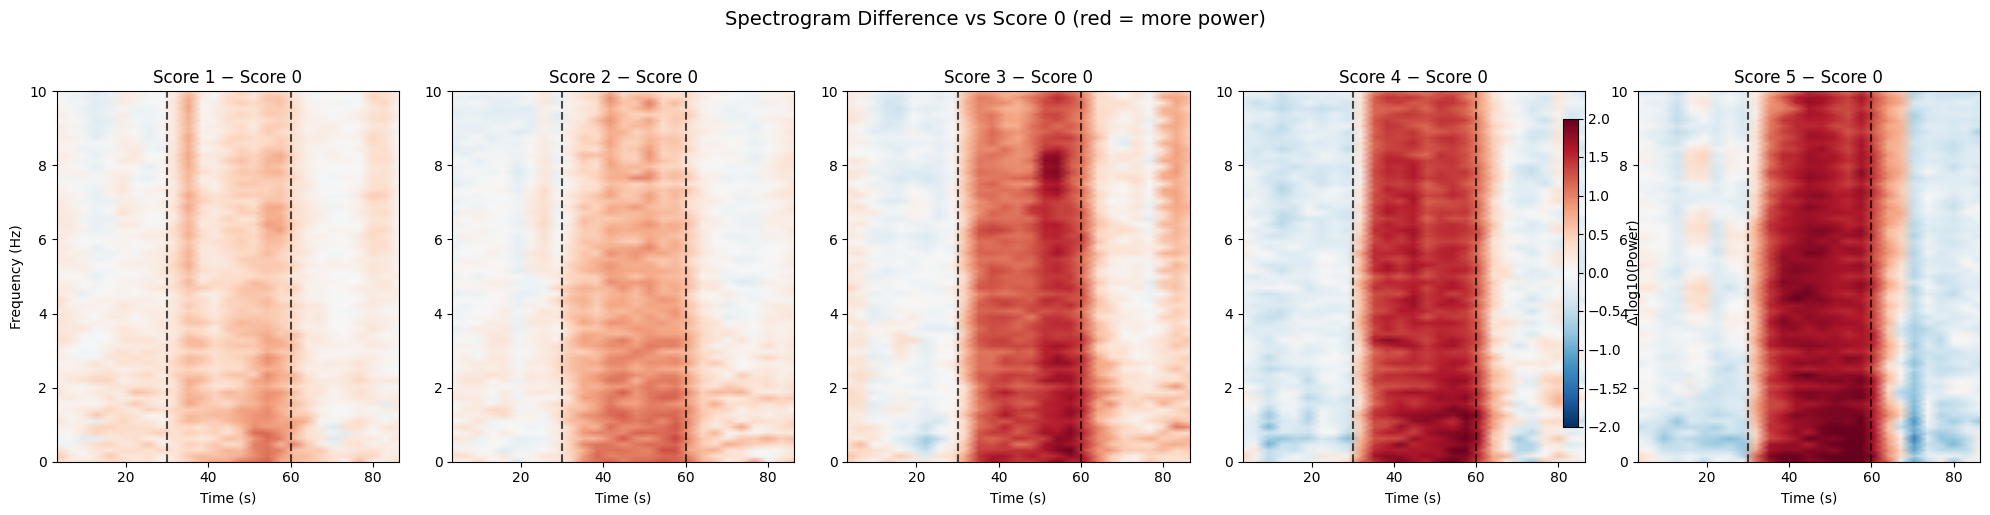

In [22]:
# Difference spectrograms: each score minus Score 0
if 0 in spectrograms_by_score:
    ref = np.log10(spectrograms_by_score[0] + 1e-10)
    diff_scores = [s for s in plot_scores if s != 0]
    
    fig, axes = plt.subplots(1, len(diff_scores), figsize=(4 * len(diff_scores), 5))
    if len(diff_scores) == 1:
        axes = [axes]
    
    diffs = [np.log10(spectrograms_by_score[s] + 1e-10) - ref for s in diff_scores]
    vlim = max(np.abs(d).max() for d in diffs)
    vlim = min(vlim, 2.0)  # cap for readability
    
    for ax, score, diff in zip(axes, diff_scores, diffs):
        im = ax.pcolormesh(t_s, f_s, diff, shading='gouraud', cmap='RdBu_r', vmin=-vlim, vmax=vlim)
        ax.set_title(f'Score {score} − Score 0')
        ax.set_ylim(0, 10)
        ax.axvline(30, color='k', linestyle='--', alpha=0.7)
        ax.axvline(60, color='k', linestyle='--', alpha=0.7)
        ax.set_xlabel('Time (s)')
        if ax == axes[0]:
            ax.set_ylabel('Frequency (Hz)')
    
    plt.colorbar(im, ax=axes, label='Δ log10(Power)', shrink=0.8)
    fig.suptitle('Spectrogram Difference vs Score 0 (red = more power)', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

## 7. Before / During / After Odor — by Score

Split each trace into 3 epochs and compare frequency content across scores.
- **Before**: frames 0–1199 (0–30s)
- **During**: frames 1200–2399 (30–60s)  
- **After**: frames 2400–3600 (60–90s)

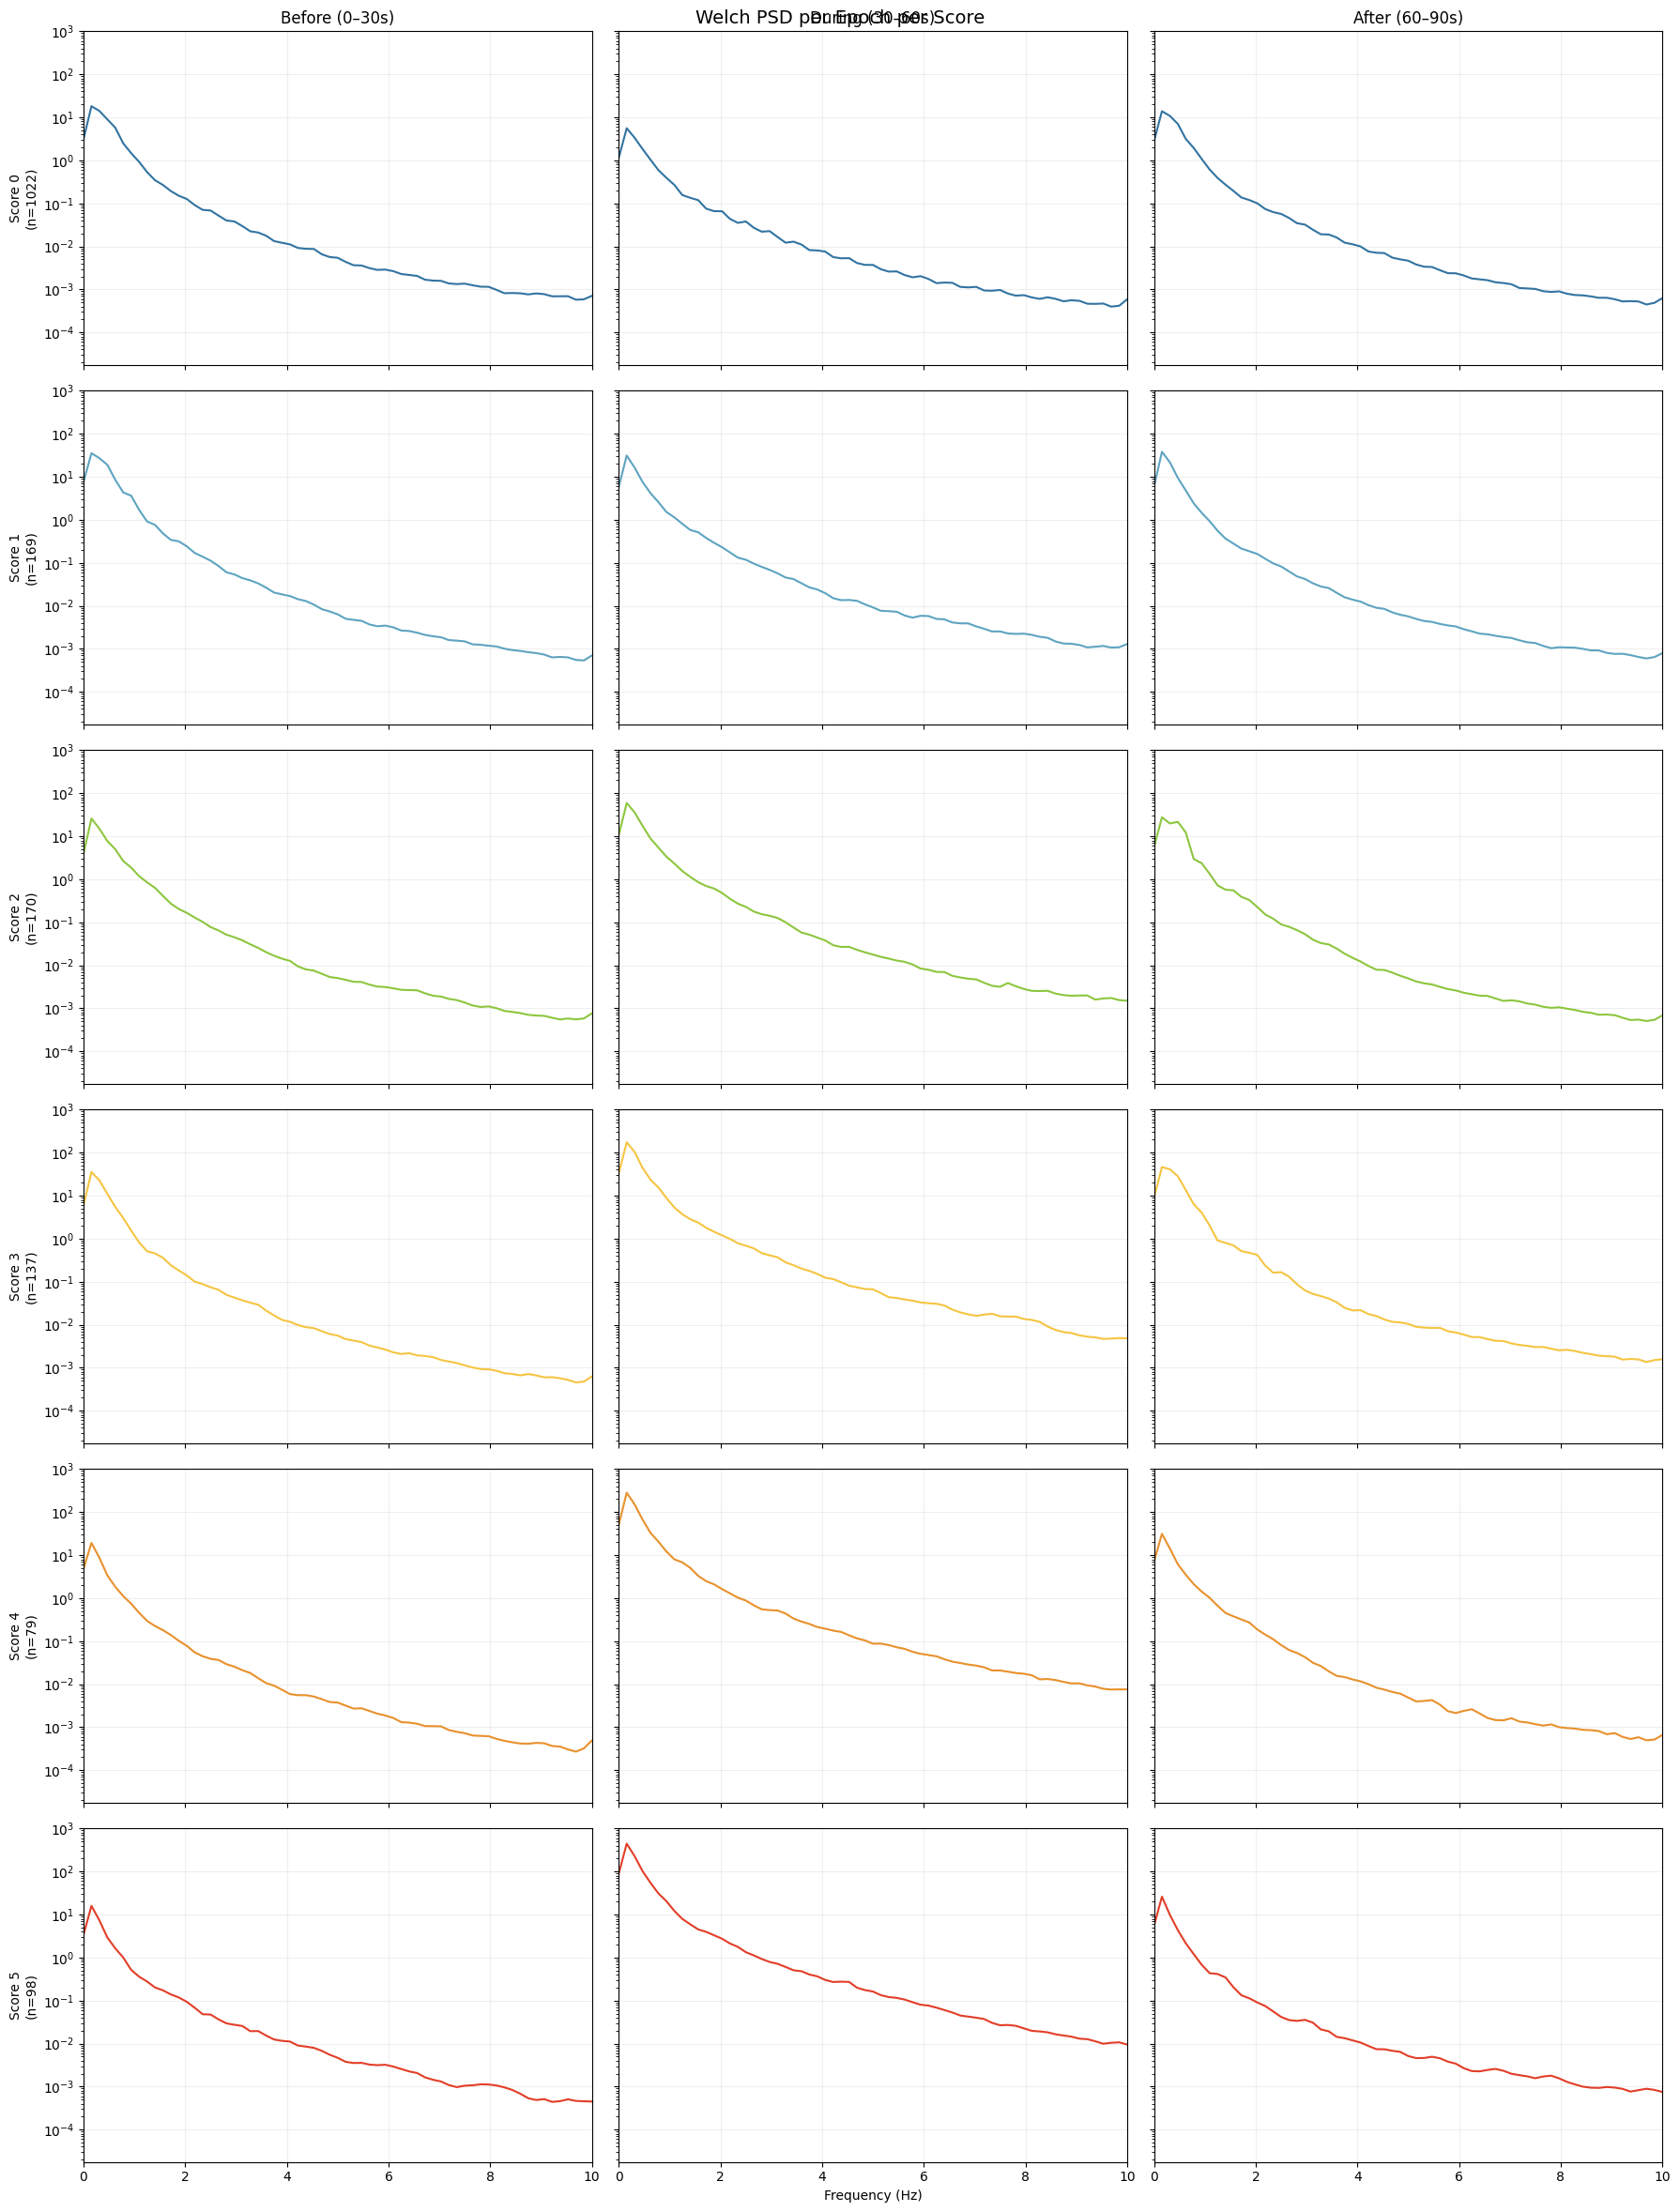

In [23]:
before = traces_mat[:, :1200]
during = traces_mat[:, 1200:2400]
after = traces_mat[:, 2400:3601]

def epoch_welch_all(traces_epoch, fps, nperseg=256):
    psds = []
    for tr in traces_epoch:
        f, pxx = signal.welch(tr - np.mean(tr), fs=fps, nperseg=nperseg, noverlap=nperseg//2)
        psds.append(pxx)
    return f, np.array(psds)

f_ep, psd_before = epoch_welch_all(before, FPS)
_, psd_during = epoch_welch_all(during, FPS)
_, psd_after = epoch_welch_all(after, FPS)

# Plot: one row per score, columns = Before/During/After
fig, axes = plt.subplots(len(unique_scores), 3, figsize=(18, 4 * len(unique_scores)), sharex=True, sharey=True)
if len(unique_scores) == 1:
    axes = axes.reshape(1, -1)

for row, score in enumerate(unique_scores):
    mask = scores_arr == score
    n = mask.sum()
    for col, (psd_epoch, epoch_name) in enumerate([
        (psd_before, 'Before (0–30s)'),
        (psd_during, 'During (30–60s)'),
        (psd_after, 'After (60–90s)')
    ]):
        ax = axes[row, col]
        mean_psd = np.mean(psd_epoch[mask], axis=0)
        ax.semilogy(f_ep, mean_psd, color=SCORE_COLORS.get(score, 'gray'), linewidth=1.5)
        if row == 0:
            ax.set_title(epoch_name)
        if col == 0:
            ax.set_ylabel(f'Score {score}\n(n={n})')
        ax.set_xlim(0, 10)
        ax.grid(True, alpha=0.2)

axes[-1, 1].set_xlabel('Frequency (Hz)')
fig.suptitle('Welch PSD per Epoch per Score', fontsize=14)
plt.tight_layout()
plt.show()

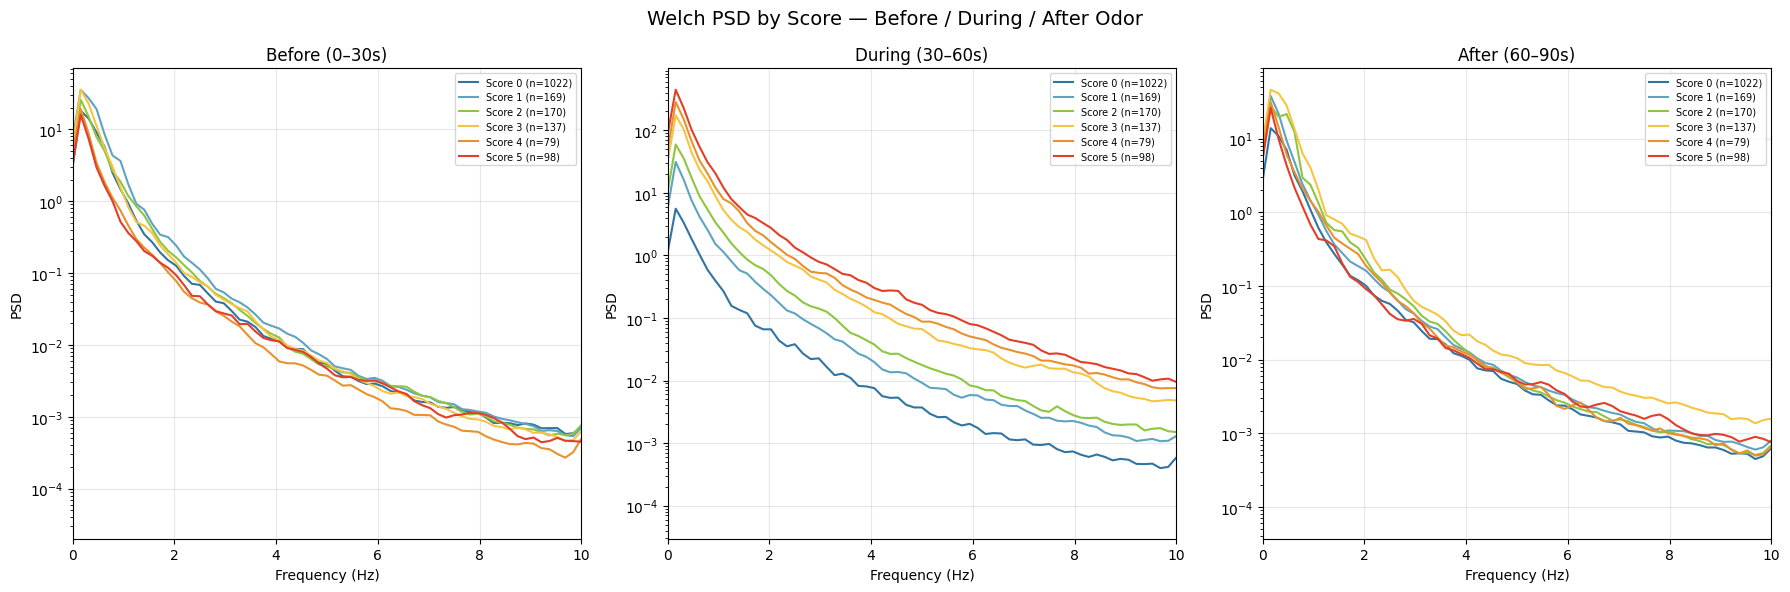

In [24]:
# More useful: overlay all scores in one plot per epoch
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (psd_epoch, epoch_name) in zip(axes, [
    (psd_before, 'Before (0–30s)'),
    (psd_during, 'During (30–60s)'),
    (psd_after, 'After (60–90s)')
]):
    for score in unique_scores:
        mask = scores_arr == score
        ax.semilogy(f_ep, np.mean(psd_epoch[mask], axis=0),
                    label=f'Score {score} (n={mask.sum()})',
                    color=SCORE_COLORS.get(score, 'gray'), linewidth=1.5)
    ax.set_title(epoch_name)
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('PSD')
    ax.set_xlim(0, 10)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

fig.suptitle('Welch PSD by Score — Before / During / After Odor', fontsize=14)
plt.tight_layout()
plt.show()

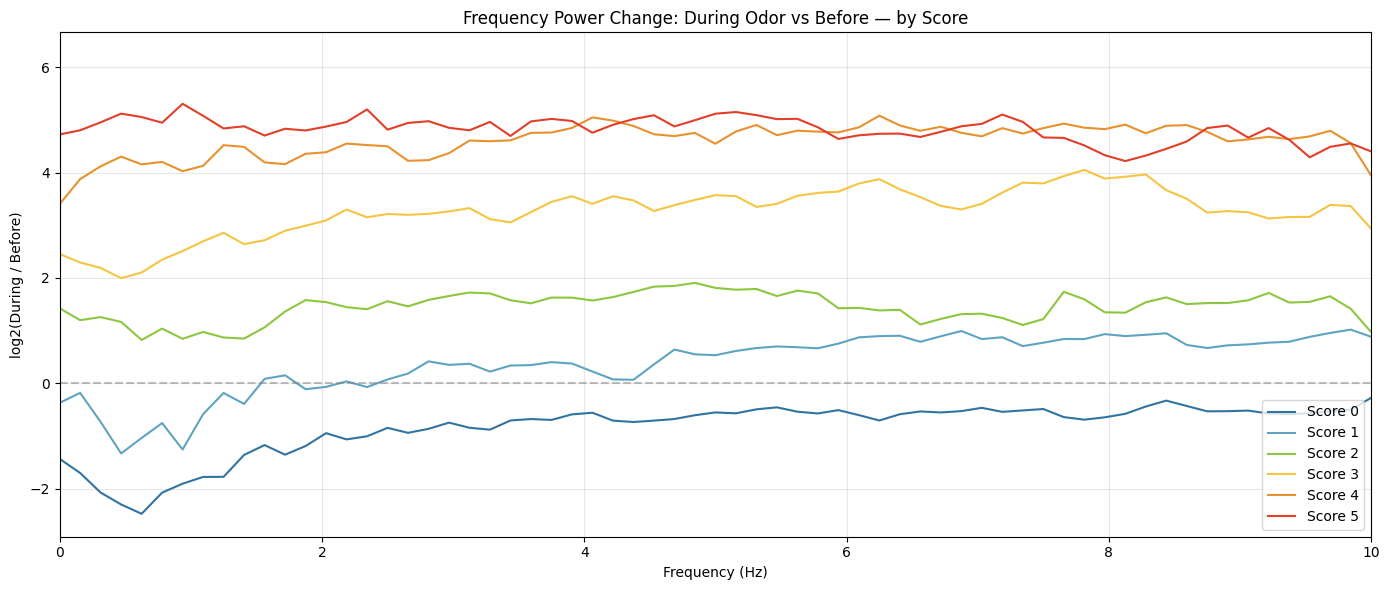

In [25]:
# During-minus-Before ratio per score — shows what changes with odor
fig, ax = plt.subplots(figsize=(14, 6))

for score in unique_scores:
    mask = scores_arr == score
    mean_before = np.mean(psd_before[mask], axis=0)
    mean_during = np.mean(psd_during[mask], axis=0)
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = np.log2(mean_during / mean_before)
    ax.plot(f_ep, ratio, label=f'Score {score}',
            color=SCORE_COLORS.get(score, 'gray'), linewidth=1.5)

ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('log2(During / Before)')
ax.set_title('Frequency Power Change: During Odor vs Before — by Score')
ax.set_xlim(0, 10)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Band Power — Statistical Tests Across Scores

In [26]:
bands = {
    'Very Low (0–0.5 Hz)': (0, 0.5),
    'Low (0.5–1 Hz)': (0.5, 1.0),
    'Mid (1–3 Hz)': (1.0, 3.0),
    'High (3–5 Hz)': (3.0, 5.0),
    'Very High (5–10 Hz)': (5.0, 10.0),
}

def band_power(psd_matrix, freqs, fmin, fmax):
    idx = (freqs >= fmin) & (freqs < fmax)
    return psd_matrix[:, idx].sum(axis=1)

# Kruskal-Wallis test (non-parametric ANOVA) across all scores
print('Kruskal-Wallis test: does band power differ across scores?')
print(f'{"Band":<25} {"H-stat":>10} {"p-value":>12}')
print('-' * 50)

for band_name, (fmin, fmax) in bands.items():
    bp = band_power(welch_psds, f_welch, fmin, fmax)
    groups = [bp[scores_arr == s] for s in unique_scores if (scores_arr == s).sum() >= 5]
    stat, pval = kruskal(*groups)
    marker = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else ''
    print(f'{band_name:<25} {stat:>10.2f} {pval:>12.4g} {marker}')

Kruskal-Wallis test: does band power differ across scores?
Band                          H-stat      p-value
--------------------------------------------------
Very Low (0–0.5 Hz)           663.91    3.11e-141 ***
Low (0.5–1 Hz)                575.45    4.07e-122 ***
Mid (1–3 Hz)                  586.57   1.612e-124 ***
High (3–5 Hz)                 584.01   5.772e-124 ***
Very High (5–10 Hz)           531.71   1.137e-112 ***


In [27]:
# Pairwise: each score vs Score 0
print('Mann-Whitney U: each score vs Score 0')
print(f'{"Band":<25}', end='')
for s in unique_scores:
    if s == 0:
        continue
    print(f'  Score {s:>2}', end='')
print()
print('-' * (25 + 10 * (len(unique_scores) - 1)))

for band_name, (fmin, fmax) in bands.items():
    bp = band_power(welch_psds, f_welch, fmin, fmax)
    bp_0 = bp[scores_arr == 0]
    print(f'{band_name:<25}', end='')
    for s in unique_scores:
        if s == 0:
            continue
        bp_s = bp[scores_arr == s]
        if len(bp_s) < 5:
            print(f'  {"n/a":>8}', end='')
            continue
        _, pval = mannwhitneyu(bp_s, bp_0, alternative='two-sided')
        marker = '***' if pval < 0.001 else '** ' if pval < 0.01 else '*  ' if pval < 0.05 else '   '
        print(f'  {pval:>6.3f}{marker}', end='')
    print()

Mann-Whitney U: each score vs Score 0
Band                       Score  1  Score  2  Score  3  Score  4  Score  5
---------------------------------------------------------------------------
Very Low (0–0.5 Hz)         0.000***   0.000***   0.000***   0.000***   0.000***
Low (0.5–1 Hz)              0.000***   0.000***   0.000***   0.000***   0.000***
Mid (1–3 Hz)                0.000***   0.000***   0.000***   0.000***   0.000***
High (3–5 Hz)               0.000***   0.000***   0.000***   0.000***   0.000***
Very High (5–10 Hz)         0.000***   0.000***   0.000***   0.000***   0.000***


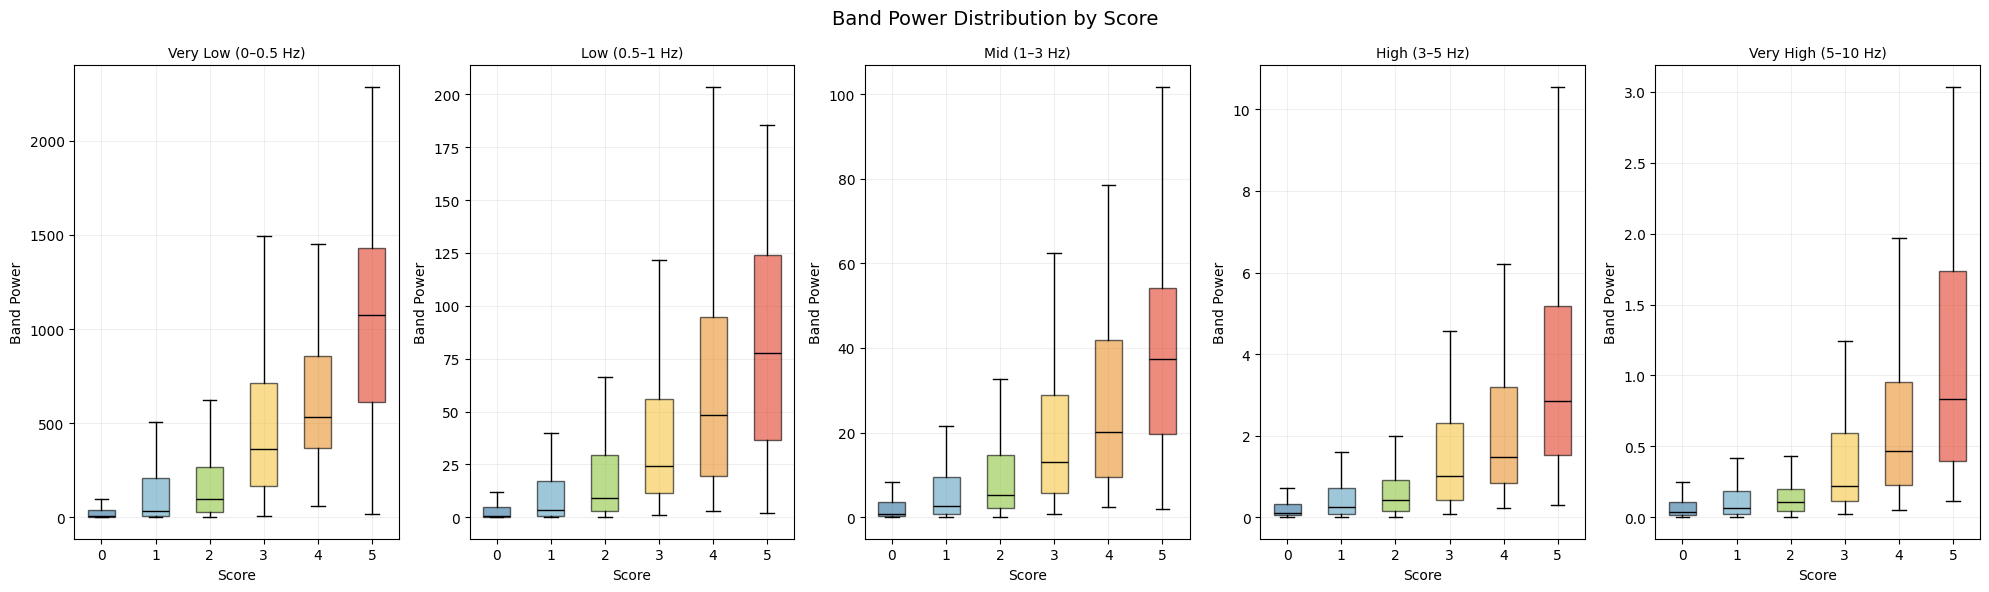

In [28]:
# Box plots of band power by score
fig, axes = plt.subplots(1, len(bands), figsize=(4 * len(bands), 6))

for ax, (band_name, (fmin, fmax)) in zip(axes, bands.items()):
    bp = band_power(welch_psds, f_welch, fmin, fmax)
    data = [bp[scores_arr == s] for s in unique_scores]
    
    bplot = ax.boxplot(data, labels=[str(s) for s in unique_scores], patch_artist=True,
                       showfliers=False, medianprops={'color': 'black'})
    for patch, score in zip(bplot['boxes'], unique_scores):
        patch.set_facecolor(SCORE_COLORS.get(score, 'gray'))
        patch.set_alpha(0.6)
    
    ax.set_title(band_name, fontsize=10)
    ax.set_xlabel('Score')
    ax.set_ylabel('Band Power')
    ax.grid(True, alpha=0.2)

fig.suptitle('Band Power Distribution by Score', fontsize=14)
plt.tight_layout()
plt.show()

## 9. Frequency Band Correlations by Score

Do high-score traces show different correlation patterns between frequency bands?

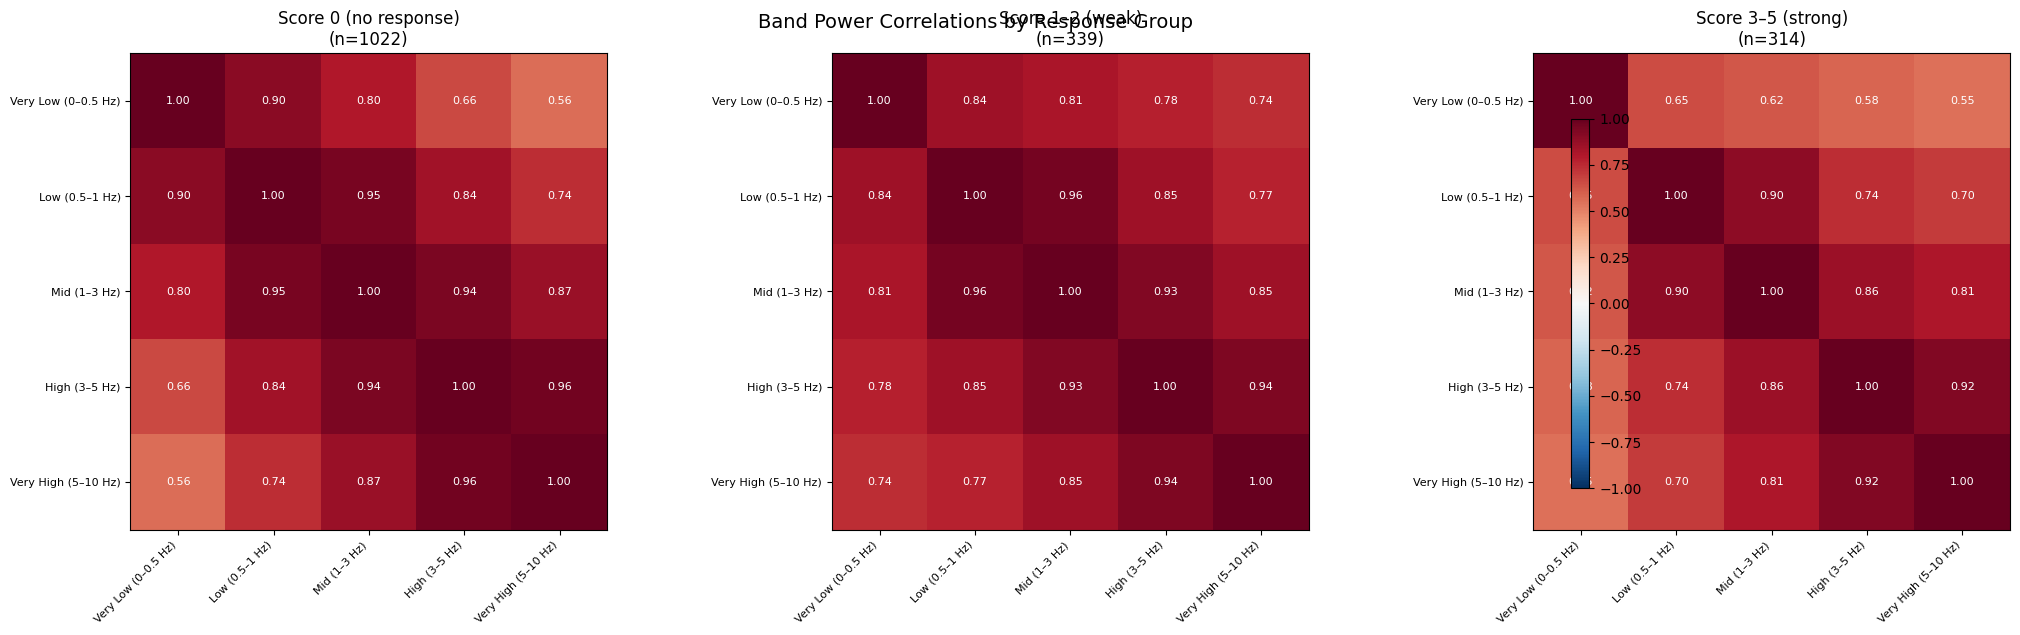

In [29]:
# Compute band powers for all traces
bp_dict = {}
for band_name, (fmin, fmax) in bands.items():
    bp_dict[band_name] = band_power(welch_psds, f_welch, fmin, fmax)
bp_all_df = pd.DataFrame(bp_dict)

# Plot correlation matrix per score group: 0, low (1-2), high (3-5)
score_groups = {
    'Score 0 (no response)': scores_arr == 0,
    'Score 1–2 (weak)': np.isin(scores_arr, [1, 2]),
    'Score 3–5 (strong)': np.isin(scores_arr, [3, 4, 5]),
}

fig, axes = plt.subplots(1, len(score_groups), figsize=(7 * len(score_groups), 6))

for ax, (group_name, group_mask) in zip(axes, score_groups.items()):
    corr = bp_all_df[group_mask].corr(method='spearman')
    im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
    ax.set_xticks(range(len(corr.columns)))
    ax.set_yticks(range(len(corr.columns)))
    ax.set_xticklabels(corr.columns, rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(corr.columns, fontsize=8)
    ax.set_title(f'{group_name}\n(n={group_mask.sum()})')
    for i in range(len(corr)):
        for j in range(len(corr)):
            ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=8,
                    color='white' if abs(corr.iloc[i,j]) > 0.5 else 'black')

plt.colorbar(im, ax=axes, shrink=0.8)
fig.suptitle('Band Power Correlations by Response Group', fontsize=14)
plt.tight_layout()
plt.show()

## 10. Summary

**Key questions answered:**
- **Do different scores have different frequency signatures?** → Check the overlay PSD plots and the Kruskal-Wallis results
- **Are there noise frequencies common to all scores?** → Look for peaks in ALL score lines at the same frequency
- **Do responders show frequency changes during odor?** → The During/Before ratio plot shows this — look for divergence between high and low scores
- **Which frequency bands best discriminate scores?** → The box plots and Mann-Whitney results show which bands differ significantly

**Next steps if signals are found:**
1. **Bandpass filter** the traces to isolate informative frequencies
2. **Use band powers as features** in your scoring classifier
3. **Wavelet analysis** for finer time-frequency resolution
4. **Coherence analysis** to check if flies respond at the same frequencies